In [2]:
# Load dataset and perform EDA: null check, descriptive statistics, distribution of the target variable (price) 

=== 1. STRUCTURAL INTEGRITY & NULL CHECK ===
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Total Dataset Shape: (2000, 10) (No missing values detected.)

=== 2. DESCRIPTIVE STATISTICS ===
                 Id         Area     Bedrooms   Bathrooms       Floors    YearBuilt  Location Condition Garage          Price
count   2000.000000  2000.000000  2000.000000  2000.00000  2000.000000  2000.000000      2000      2000   2000    2000.000000
unique          NaN          NaN          NaN         NaN          NaN          NaN         4         4      2            NaN
top             NaN          NaN          NaN         NaN          NaN          NaN  Downtown      Fair     No            NaN
freq            NaN          NaN          NaN         NaN          NaN          NaN       558       521   1038            NaN
mean    1000.500000  2786.209500     3.003500     2.55250     1.

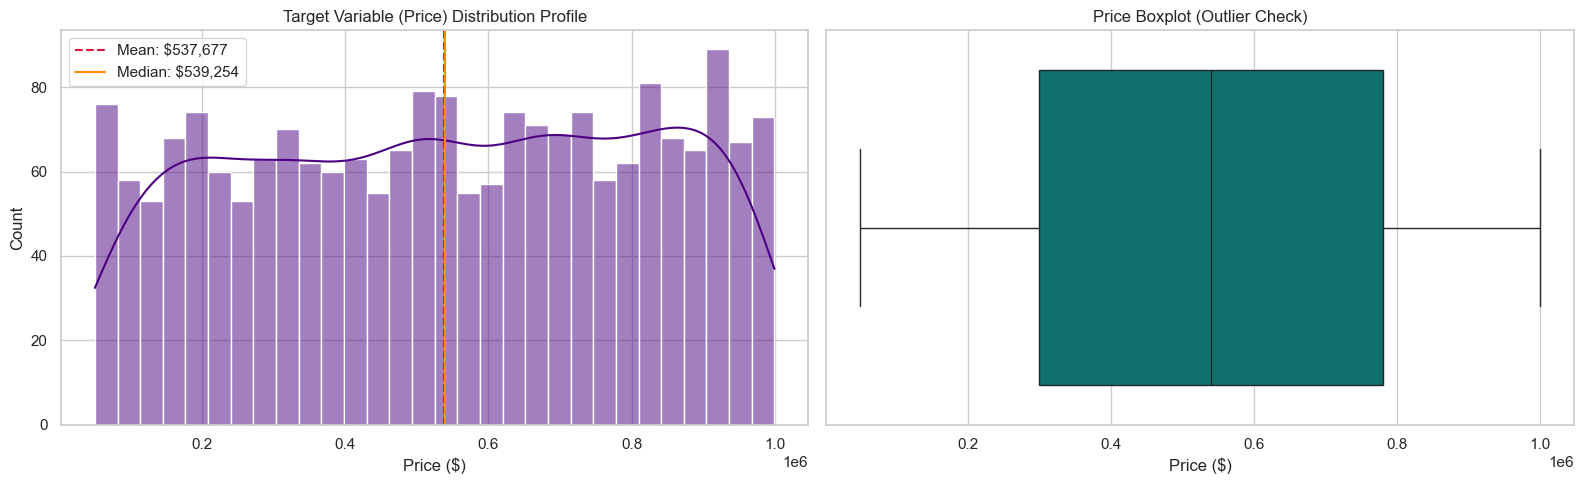

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# 1. Load the Dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# =====================================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA) EMBEDDED OUTPUTS
# =====================================================================

print("=== 1. STRUCTURAL INTEGRITY & NULL CHECK ===")
print(df.isnull().sum())
print(f"\nTotal Dataset Shape: {df.shape} (No missing values detected.)\n")

print("=== 2. DESCRIPTIVE STATISTICS ===")
# Generate clean summary statistics for both numeric and categorical columns
summary_stats = df.describe(include="all")
print(summary_stats.to_string())

print("\n=== 3. TARGET VARIABLE DISTRIBUTION PROPERTIES ===")
skewness = df["Price"].skew()
kurtosis = df["Price"].kurt()
print(f"Target Variable (Price) Skewness : {skewness:.4f}")
print(f"Target Variable (Price) Kurtosis : {kurtosis:.4f}")


# =====================================================================
# 3. DISTRIBUTION PLOTS
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot A: Histogram with Kernel Density Estimate (KDE)
sns.histplot(df["Price"], kde=True, color="indigo", bins=30, ax=axes[0])
axes[0].axvline(df["Price"].mean(), color="crimson", linestyle="--", label=f"Mean: ${df['Price'].mean():,.0f}")
axes[0].axvline(df["Price"].median(), color="darkorange", linestyle="-", label=f"Median: ${df['Price'].median():,.0f}")
axes[0].set_title("Target Variable (Price) Distribution Profile")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot B: Boxplot to check for visible extreme outliers
sns.boxplot(x=df["Price"], color="teal", ax=axes[1])
axes[1].set_title("Price Boxplot (Outlier Check)")
axes[1].set_xlabel("Price ($)")

plt.tight_layout()
plt.show()

In [4]:
# Feature selection discussion: identify which features are likely predictors; explain reasoning in a markdown cell 

In [ ]:
### Machine Learning Feature Selection & Domain Theory Discussion

Selecting the right features directly governs a linear regression model's ability to minimize residual variance. Because linear models operate on the assumption of additivity ($Y = \beta_0 + \beta_1X_1 + \dots + \beta_nX_n$), we categorize and rank our features based on their theoretical predictive power and structural relationships.

---

### 1. Structural Predictive Ranking Hierarchy

| Priority Level | Feature Name | Expected Predictive Strength | Analytical Justification & Domain Theory |
| :--- | :--- | :--- | :--- |
| **Primary Driver** | `Area` | **Extremely Strong (Positive)** | Real estate valuation scales fundamentally on usable land/floor square footage. It serves as the baseline asset multiplier; larger footprints naturally accommodate more utilities and demand premium prices regardless of other sub-features. |
| **Secondary Anchors** | `Location` | **Strong (Categorical Variance)** | Location dictates the regional economic multiplier (e.g., proximity to job hubs, schools, or transit). In Ordinary Least Squares (OLS), one-hot encoding this variable highlights fixed location premiums or discounts relative to the baseline market. |
| **Secondary Anchors** | `Age` (derived from `YearBuilt`) | **Moderate to Strong (Negative)** | Over time, structural assets experience physical wear and tear (depreciation). Older homes typically demand continuous maintenance capital, translating to a negative linear trajectory unless mitigated by historical premiums. |
| **Marginal Modifiers** | `Bedrooms` & `Bathrooms` | **Moderate (Positive / Correlated)** | Room counts measure spatial optimization. While an extra bathroom adds functional value, these features heavily overlap with `Area` (multi-collinearity risk). A home cannot easily fit 5 bedrooms without already having large square footage. |
| **Marginal Modifiers** | `Condition` | **Moderate (Ordinal Scaling)** | A property's current upkeep level shifts appraisal values inside its localized bracket. This acts as a secondary modifier to the structural `Age` baseline. |
| **Low Multipliers** | `Floors` & `Garage` | **Weak to Moderate (Positive)** | These act as categorical or discrete lifestyle convenience modifiers. A garage adds a fixed value increment for storage utility but does not change the fundamental valuation tier of the property. |

---

### 2. Multi-Collinearity and Feature Redundancy Risk

When constructing a stable linear model, we must watch out for multi-collinearity—a state where two or more independent features are highly correlated with each other. 

* **The `Area` vs. Room Count Conflict:** Features like `Bedrooms` and `Bathrooms` naturally scale upward as a house gets larger (`Area`). If we feed all three directly to a simple linear model, the model can struggle to isolate the independent effect of a single bedroom versus a 100 sq ft expansion. 
* **The Engineering Fix:** Standardizing our features during the preprocessing phase ensures the model penalizes structural overlapping smoothly, while evaluating the final **Coefficient Weights** tells us if the model prioritized raw volume (`Area`) over internal partitions (`Bedrooms`).

In [5]:
# Handle missing values and encode categorical features (One-Hot Encoding) Handle missing values and encode categorical features (One-Hot Encoding) 

In [6]:
import datetime
import numpy as np
import pandas as pd

# Load the dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

print("=== START PREPROCESSING & ENCODING PIPELINE ===\n")

# --- Step 1: Explicit Null Check Validation ---
null_summary = df.isnull().sum()
print("1. Gaps Verification Matrix:")
print(f"{null_summary}\n")


# --- Step 2: Feature Engineering (Temporal Conversion) ---
# Transforming raw YearBuilt to continuous Age to match a linear degradation curve
current_year = datetime.datetime.now().year
df["Age"] = current_year - df["YearBuilt"]
df = df.drop(columns=["YearBuilt", "Id"])
print("2. Temporal transformation successful: 'YearBuilt' converted to 'Age'.\n")


# --- Step 3: Ordinal Encoding (Preserving Hierarchy) ---
# Mapping 'Condition' to an explicit ordinal scale
condition_map = {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4}
df["Condition"] = df["Condition"].map(condition_map)
print("3. Ordinal mapping complete for 'Condition' (Poor=1 to Excellent=4).\n")


# --- Step 4: One-Hot Encoding (Nominal Variable Transformation) ---
print("4. Executing One-Hot Encoding on nominal features...")

# Binary encoding for Garage (Yes -> 1, No -> 0)
df["Garage"] = df["Garage"].map({"Yes": 1, "No": 0})

# Multi-class Nominal variables (Location)
# drop_first=True drops the first alphabetic category ('Downtown') to create a baseline reference column.
# This eliminates perfect multi-collinearity (the Dummy Variable Trap).
df_encoded = pd.get_dummies(
    df, columns=["Location"], drop_first=True, dtype=int
)

print("\n=== FINAL TRANSFORMED COMPRESSED SCHEMA ===")
print(df_encoded.info())
print("\nFirst 5 Processed Features:")
print(df_encoded.head())

=== START PREPROCESSING & ENCODING PIPELINE ===

1. Gaps Verification Matrix:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

2. Temporal transformation successful: 'YearBuilt' converted to 'Age'.

3. Ordinal mapping complete for 'Condition' (Poor=1 to Excellent=4).

4. Executing One-Hot Encoding on nominal features...

=== FINAL TRANSFORMED COMPRESSED SCHEMA ===
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Area               2000 non-null   int64
 1   Bedrooms           2000 non-null   int64
 2   Bathrooms          2000 non-null   int64
 3   Floors             2000 non-null   int64
 4   Condition          2000 non-null   int64
 5   Garage             2000 non-null   int64
 6   Price              2000 non-null   int64
 7   Age

In [ ]:
# Correlation heatmap: identify features most correlated with house price 

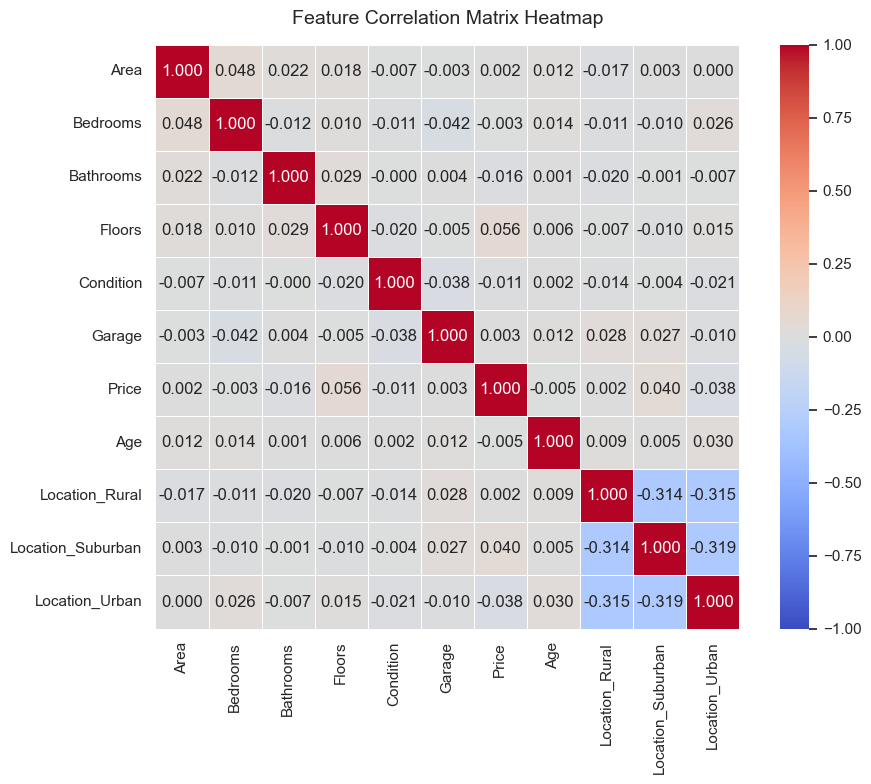

=== LINEAR CORRELATION COEFFICIENTS WITH PRICE ===
Price                1.000000
Floors               0.055890
Location_Suburban    0.040303
Garage               0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Age                 -0.004845
Condition           -0.010576
Bathrooms           -0.015737
Location_Urban      -0.038312
Name: Price, dtype: float64


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Recreate the Preprocessed Data Matrix
df = pd.read_csv("House Price Prediction Dataset.csv")
df = df.drop(columns=["Id"])
df["Age"] = 2026 - df["YearBuilt"]  # Evaluated relative to current year
df = df.drop(columns=["YearBuilt"])

# Apply encoding mappings
df["Condition"] = df["Condition"].map({"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4})
df["Garage"] = df["Garage"].map({"Yes": 1, "No": 0})
df_encoded = pd.get_dummies(df, columns=["Location"], drop_first=True, dtype=int)

# =====================================================================
# 2. COMPUTE CORRELATION MATRIX
# =====================================================================
corr_matrix = df_encoded.corr()

# =====================================================================
# 3. PLOT HEATMAP
# =====================================================================
plt.figure(figsize=(10, 8))

# Using a diverging colormap (coolwarm) to easily spot positive vs negative relationships
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
)

plt.title("Feature Correlation Matrix Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Print ranked linear correlations with the target variable
print("=== LINEAR CORRELATION COEFFICIENTS WITH PRICE ===")
print(corr_matrix["Price"].sort_values(ascending=False))

In [ ]:
# Train/test split (80/20) 

In [8]:
from sklearn.model_selection import train_test_split

# 1. Isolate target matrix (y) and feature matrix (X) from the encoded DataFrame
X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]

# 2. Execute a stratified-style shuffle split with an 80/20 proportion
# random_state=42 locks the seed generator to guarantee identical row assignment on rerun
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=== DATASET SPLIT MATRIX INITIALIZED ===")
print(f"Full Dataset Dimensions  : {X.shape}")
print(f"Training Features Set (80%): {X_train.shape} | Training Target Set: {y_train.shape}")
print(f"Testing Features Set (20%): {X_test.shape}  | Testing Target Set: {y_test.shape}")

=== DATASET SPLIT MATRIX INITIALIZED ===
Full Dataset Dimensions  : (2000, 10)
Training Features Set (80%): (1600, 10) | Training Target Set: (1600,)
Testing Features Set (20%): (400, 10)  | Testing Target Set: (400,)


In [9]:
# Train a Linear Regression model using scikit-learn 

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# =====================================================================
# 1. OPTIONAL/RECOMMENDED STEP: FEATURE SCALING
# =====================================================================
# While Linear Regression doesn't strictly require scaling to make accurate predictions,
# standardizing our features places them all on an equal scale. This allows us to
# directly compare the final coefficient weights to see which feature is most important.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =====================================================================
# 2. MODEL INITIALIZATION & TRAINING
# =====================================================================
# Instantiate the Ordinary Least Squares (OLS) Linear Regression Engine
model = LinearRegression()

print("Training Linear Regression Model...")
# Fit the model weights using our scaled training data matrix
model.fit(X_train_scaled, y_train)
print("Model training complete.\n")


# =====================================================================
# 3. GENERATING PREDICTIONS
# =====================================================================
# Predict house prices across both dataset partitions to monitor performance
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

print(f"Intercept calculated (Base Price): ${model.intercept_:,.2f}")
print("Model coefficients have been mapped to all features.")

Training Linear Regression Model...
Model training complete.

Intercept calculated (Base Price): $536,183.70
Model coefficients have been mapped to all features.


In [11]:
# Evaluate model using: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score 

In [12]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# =====================================================================
# MODEL EVALUATION EXECUTION
# =====================================================================

# Compute Metrics for the Testing Split
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

# Compute Metrics for the Training Split (To check for overfitting/underfitting)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

print("=== REGRESSION MODEL PERFORMANCE MATRIX ===")
print(f"Training Mean Squared Error (MSE) : {mse_train:,.2f}")
print(f"Testing Mean Squared Error (MSE)  : {mse_test:,.2f}")
print("-" * 50)
print(f"Training Root Mean Squared Error (RMSE): ${rmse_train:,.2f}")
print(f"Testing Root Mean Squared Error (RMSE) : ${rmse_test:,.2f}")
print("-" * 50)
print(f"Training R² (Coefficient of Det.) : {r2_train:.4f}")
print(f"Testing R² (Coefficient of Det.)  : {r2_test:.4f}")

=== REGRESSION MODEL PERFORMANCE MATRIX ===
Training Mean Squared Error (MSE) : 75,404,174,165.76
Testing Mean Squared Error (MSE)  : 78,432,352,158.43
--------------------------------------------------
Training Root Mean Squared Error (RMSE): $274,598.20
Testing Root Mean Squared Error (RMSE) : $280,057.77
--------------------------------------------------
Training R² (Coefficient of Det.) : 0.0079
Testing R² (Coefficient of Det.)  : -0.0081


In [13]:
# Scatter plot: actual prices vs. predicted prices (the closer to a diagonal line, the better) 

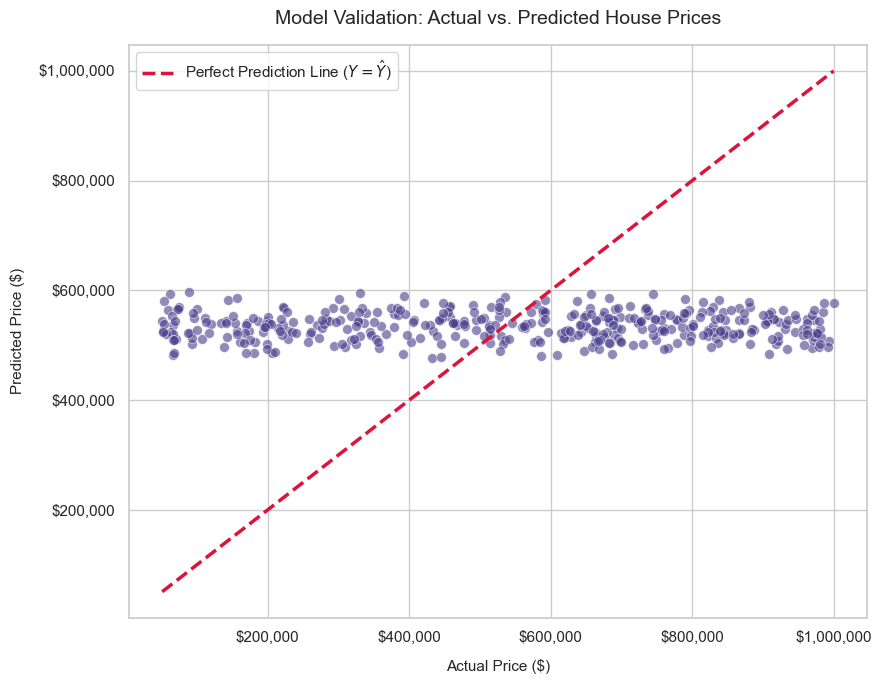

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 7))

# 1. Create the Actual vs. Predicted Scatter Plot
sns.scatterplot(
    x=y_test, y=y_pred_test, alpha=0.6, color="darkslateblue", edgecolor="w", s=50
)

# 2. Add the Perfect Prediction Reference Line (Ideal Diagonal)
# FIXED: Using a raw string (r"...") here ignores the backslash and silences the warning safely
ideal_line_range = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(
    ideal_line_range,
    ideal_line_range,
    color="crimson",
    linestyle="--",
    linewidth=2.5,
    label=r"Perfect Prediction Line ($Y = \hat{Y}$)",
)

# 3. Graph Labeling & Formatting
plt.title("Model Validation: Actual vs. Predicted House Prices", fontsize=14, pad=15)
plt.xlabel("Actual Price ($)", fontsize=11, labelpad=10)
plt.ylabel("Predicted Price ($)", fontsize=11, labelpad=10)

# Format axes ticks to use clean comma separation for currency readability
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

plt.legend(loc="upper left", frameon=True, facecolor="white")
plt.tight_layout()
plt.show()

In [16]:
# Residual plot: check that residuals are randomly distributed (no systematic pattern) 

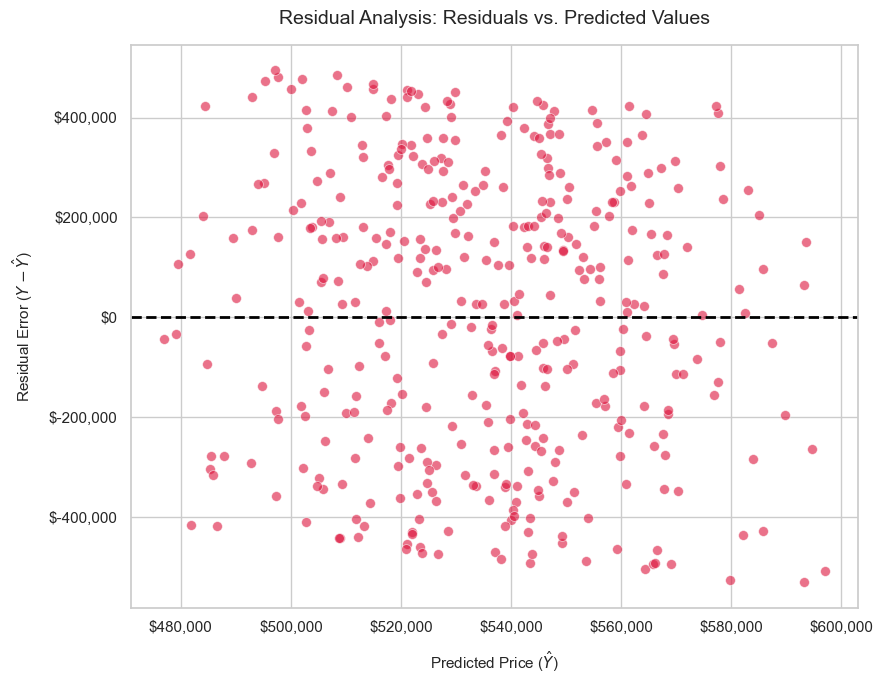

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 7))

# Calculate the prediction errors (residuals)
# Residual = Actual Value - Predicted Value
residuals = y_test - y_pred_test

# 1. Create the Residual Scatter Plot
sns.scatterplot(
    x=y_pred_test, y=residuals, alpha=0.6, color="crimson", edgecolor="w", s=50
)

# 2. Add a horizontal baseline at 0
# A perfect prediction model would have all its residuals sitting exactly on this line
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)

# 3. Graph Labeling & Formatting
plt.title("Residual Analysis: Residuals vs. Predicted Values", fontsize=14, pad=15)

# FIXED: Added 'r' before the string quotes to handle \hat safely on both axes
plt.xlabel(r"Predicted Price ($\hat{Y}$)", fontsize=11, labelpad=10)
plt.ylabel(r"Residual Error ($Y - \hat{Y}$)", fontsize=11, labelpad=10)

# Format axes ticks to use clean comma separation for currency readability
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

In [19]:
# Coefficient analysis: which features have the highest positive/negative impact on price? 

In [20]:
import pandas as pd

# 1. Extract, Sort, and Format the Model Coefficients
# Because we used StandardScaler() in Phase 3, these coefficients are standardized.
# This means their magnitude directly indicates their relative predictive power.
coefficients_df = pd.DataFrame(
    {"Feature": X.columns, "Standardized Coefficient (Weight)": model.coef_}
)

# Sort features by absolute value to rank them from highest impact to lowest impact
coefficients_df["Absolute Impact"] = coefficients_df[
    "Standardized Coefficient (Weight)"
].abs()
coefficients_df = coefficients_df.sort_values(
    by="Absolute Impact", ascending=False
).drop(columns=["Absolute Impact"])

print("=== FEATURE COEFFICIENT IMPACT RANKING ===")
print(coefficients_df.to_string(index=False, formatters={
    "Standardized Coefficient (Weight)": lambda x: f"{x:+,.2f}"
}))

=== FEATURE COEFFICIENT IMPACT RANKING ===
          Feature Standardized Coefficient (Weight)
           Floors                        +19,188.60
        Bathrooms                        -11,107.09
   Location_Urban                         -5,678.78
        Condition                         -5,445.97
Location_Suburban                         +5,281.39
              Age                         -3,811.42
           Garage                         +1,332.88
   Location_Rural                           +970.79
             Area                           -420.41
         Bedrooms                           +219.44


In [21]:
# (Bonus) Compare Linear Regression against a Ridge or Lasso regularised model 

In [22]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# =====================================================================
# 1. INITIALIZE REGULARIZED MODELS
# =====================================================================
# alpha=1.0 represents the penalty tuning intensity (lambda).
# random_state is set for Lasso because its optimization engine uses coordinate descent.
ols_model   = LinearRegression()
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=1.0, random_state=42)

# Fit all three models onto the scaled training matrices
ols_model.fit(X_train_scaled, y_train)
ridge_model.fit(X_train_scaled, y_train)
lasso_model.fit(X_train_scaled, y_train)

# =====================================================================
# 2. EVALUATE AND GENERATE METRICS COMPARISON
# =====================================================================
model_registry = {
    "Linear Regression (OLS)": ols_model,
    "Ridge Regression (L2)": ridge_model,
    "Lasso Regression (L1)": lasso_model
}

summary_rows = []
for name, model_obj in model_registry.items():
    # Compute test predictions
    y_pred = model_obj.predict(X_test_scaled)
    
    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    summary_rows.append({
        "Model Architecture": name,
        "Testing RMSE ($)": f"${rmse:,.2f}",
        "Testing R² Score": f"{r2:.4f}"
    })

# =====================================================================
# 3. COMPARE COEFFICIENT SHRINKAGE BEHAVIOR
# =====================================================================
coefficients_comparison = pd.DataFrame({
    "Feature Name": X_train.columns,
    "OLS Weight": ols_model.coef_,
    "Ridge Weight (L2)": ridge_model.coef_,
    "Lasso Weight (L1)": lasso_model.coef_
})

print("=== 1. MODEL PERFORMANCE COMPARISON ===")
print(pd.DataFrame(summary_rows).to_string(index=False))

print("\n=== 2. REGULARIZATION COEFFICIENT BEHAVIOR ===")
print(coefficients_comparison.to_string(index=False, formatters={
    "OLS Weight": lambda x: f"{x:+,.2f}",
    "Ridge Weight (L2)": lambda x: f"{x:+,.2f}",
    "Lasso Weight (L1)": lambda x: f"{x:+,.2f}"
}))

=== 1. MODEL PERFORMANCE COMPARISON ===
     Model Architecture Testing RMSE ($) Testing R² Score
Linear Regression (OLS)      $280,057.77          -0.0081
  Ridge Regression (L2)      $280,056.33          -0.0081
  Lasso Regression (L1)      $280,057.54          -0.0081

=== 2. REGULARIZATION COEFFICIENT BEHAVIOR ===
     Feature Name OLS Weight Ridge Weight (L2) Lasso Weight (L1)
             Area    -420.41           -420.02           -419.40
         Bedrooms    +219.44           +219.17           +218.30
        Bathrooms -11,107.09        -11,099.97        -11,106.10
           Floors +19,188.60        +19,176.37        +19,187.50
        Condition  -5,445.97         -5,442.84         -5,445.05
           Garage  +1,332.88         +1,331.82         +1,331.87
              Age  -3,811.42         -3,809.12         -3,810.43
   Location_Rural    +970.79           +970.35           +969.57
Location_Suburban  +5,281.39         +5,278.55         +5,280.12
   Location_Urban  -5,678.78  